# Kubernetes = K85
Kubernetes is an open-source container orchestration platform used to automate deployment, scaling, and management of containerized applications. It follows a master-worker architecture where the control plane manages the cluster and worker nodes run applications. Key components include API server, scheduler, controller manager, etcd, kubelet, and pods, which together ensure high availability and scalability.

# Kubernetes/Cluster Architecture
Kubernetes follows a client–server architecture consisting of a control plane (master) and worker nodes. The control plane includes components such as the API Server, Scheduler, Controller Manager, and etcd for cluster state storage.

Worker nodes run application workloads and include kubelet for communication with the control plane, kube-proxy for networking, and a container runtime (such as containerd or Docker) to manage containers.

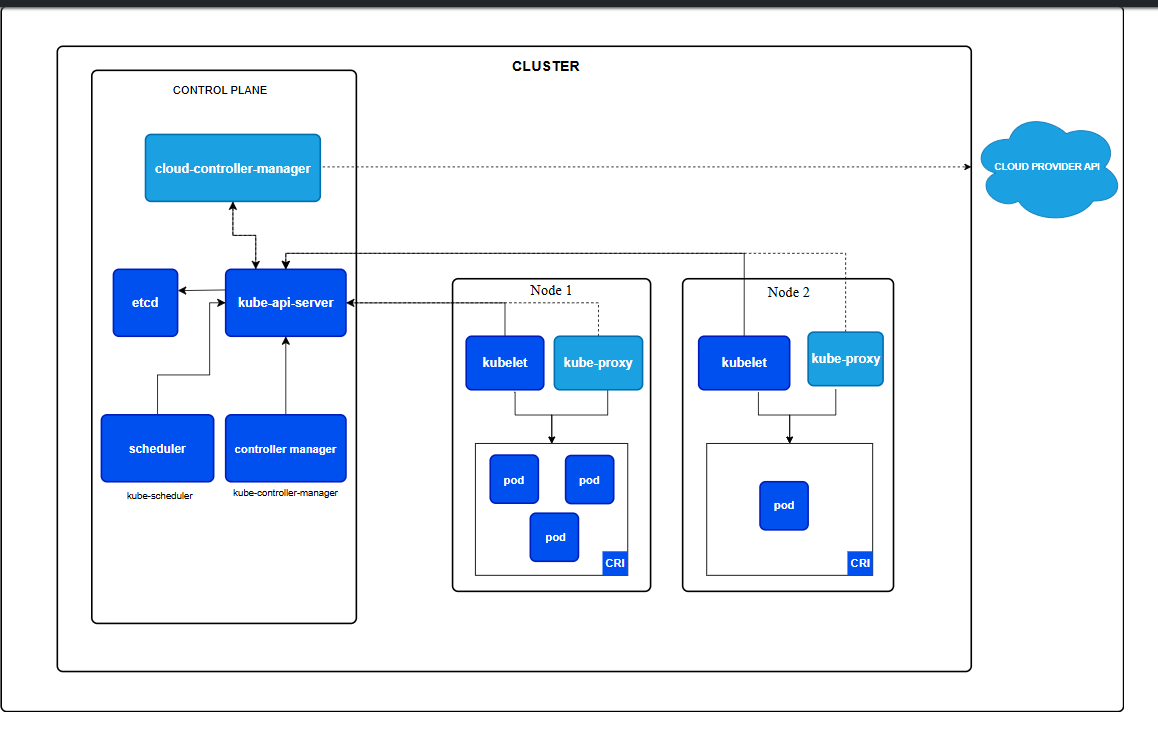

User → API Server → Scheduler → Node → Pod → Running App ✅

# CONTROL PLANE 
It is basically a collection of various components that help us in managing the overall health of a cluster.
This entire left box is: CONTROL PLANE ✅
👉 It manages the cluster
👉 It does NOT run applications

✅ Components inside Control Plane

🔷 kube-api-server (MOST IMPORTANT ⭐)
The API server is a component of the Kubernetes control plane that exposes the Kubernetes API. It is like an initial gateway to the cluster that listens to updates or queries via CLI like Kubectl.

- Kubectl communicates with API Server to inform what needs to be done like creating pods or deleting pods etc. It also works as a gatekeeper.
- It generally validates requests received and then forwards them to other processes.
- No request can be directly passed to the cluster, it has to be passed through the API Server.

✅ Role:
Entry point 
Accepts all requests 
Communicates with all components 

✅ Flow:
kubectl → API Server

🔷 etcd (DATABASE)
- A consistent, high-availability key-value store.
- Stores all cluster data (the "Source of Truth"). If it isn't in etcd, it doesn't exist in Kubernetes.

✅ Role:
Stores cluster data ✅
Stores state ✅

Example:
How many pods running ✅  
Which node has what ✅  

🔷 Scheduler
Watches for newly created Pods that have no assigned node.
Selects the best Worker Node for a Pod based on resource requirements, policy constraints, and hardware/software limits.

✅ Role:
Decides → which node runs pod ✅

👉 Flow:
Pod request → scheduler → assign Node 1 or Node 2 ✅

🔷 Controller Manager
- Runs controller processes that maintain the "desired state" of the cluster.
- Node Controller: Monitors node health.
- Replication Controller: Ensures the correct number of Pod replicas are running.

✅ Role:
Maintains desired state ✅

Example:
Need 3 pods → only 2 running  
→ create 1 more ✅

🔷 ✅ 2.5 Cloud Controller Manager
👉 Top box: cloud-controller-manager ✅

✅ Role:
Communicates with cloud provider ✅

👉 In image:
cloud-controller-manager → Cloud Provider API ✅

# Worker Node Components
These are the nodes where the actual work happens. Each Node can have multiple pods and pods have containers running inside them. There are 3 processes in every Node that are used to Schedule and manage those pods. The following are the some of the components related to Node:

1. Container runtime
The software responsible for actually running the containers (e.g., containerd, CRI-O).
It pulls images from a registry and starts/stops the containers.
2. kubelet
An agent that runs on each node in the cluster.
Ensures that containers are running in a Pod by following instructions (PodSpecs) from the Control Plane.
Reports the health and status of the node back to the API server.
3. kube-proxy
A network proxy that maintains network rules on nodes.
Allows network communication to your Pods from inside or outside of the cluster.
Handles service discovery and load balancing.

# Create Kubernetes cluster using Kind

✅ What is KIND?
KIND is a tool that allows running Kubernetes clusters using Docker containers.
KIND = Kubernetes inside Docker ✅

⭐ 2. Prerequisites

✅ Required:
AWS EC2 Instance
Ubuntu OS
Docker installed
Internet access

✅ Recommended configuration:
Instance Type → t2.medium ✅  
Storage → 30 GB ✅  

⭐ 3. Step‑by‑Step Setup

🔷 ✅ Step 1: Create EC2 Instance
👉 Create EC2 with:
Ubuntu OS
t2.medium
30GB storage
🔷 ✅ Step 2: Connect via SSH
ssh -i <key.pem> ubuntu@<public-ip>

🔷 ✅ Step 3: Install Docker (VERY IMPORTANT FIRST)
sudo apt update
sudo apt install docker.io -y

✅ Start Docker
sudo systemctl start docker
sudo systemctl enable docker

✅ Avoid sudo (optional best practice) (make current user not use sudo on every comment)
sudo usermod -aG docker $USER

🔷 ✅ Step 4: Install kubectl and KIND
✅ Create install script
vim install_kind.sh
✅ Add content (IMPORTANT ⭐ get it from google)
# Install kubectl
curl -LO "https://dl.k8s.io/release/$(curl -L -s https://dl.k8s.io/release/stable.txt)/bin/linux/amd64/kubectl"
chmod +x kubectl
sudo mv kubectl /usr/local/bin/

# Install kind
curl -Lo ./kind https://kind.sigs.k8s.io/dl/latest/kind-linux-amd64
chmod +x kind
sudo mv ./kind /usr/local/bin/

✅ Give permission
chmod +x install_kind.sh

✅ Execute script
./install_kind.sh

🔷 ✅ Step 5: Verify Installation
docker --version
kubectl version --client
kind --version

🔷 ✅ Step 6: Create Cluster Configuration
mkdir kind-cluster
cd kind-cluster
vim config.yml

✅ config.yml (Corrected version)
kind: Cluster
apiVersion: kind.x-k8s.io/v1alpha4
name: tws-cluster

nodes:
- role: control-plane
  image: kindest/node:v1.30.0
  extraPortMappings:
    - containerPort: 30080
      hostPort: 8080
      protocol: TCP

- role: worker
  image: kindest/node:v1.30.0

- role: worker
  image: kindest/node:v1.30.0

🔷 ✅ Step 7: Create Kubernetes Cluster
kind create cluster --name first-cluster --config=config.yml

🔷 ✅ Step 8: Verify Cluster Info
kubectl cluster-info

🔷 ✅ Step 9: Check Nodes
kubectl get nodes

🔷 ✅ Step 10: Set Context (IMPORTANT)
kubectl config use-context kind-first-cluster

Note : we can create cluster with minikube cluster and kubeadm as well. (follow the kubestarter github to install minikube).

# Imp Notes (this is needs to be done in kubernetes) : Namespace = Container (nginx,mysql,mongodb...)->Pod->Deployment->Service->User

kubectl get namespace or kubectl get ns ( To get all the namespace)
kubectl get pods -n kube-system (it will show all pods which is running under namespace kube-system)

Overall Flow (VERY IMPORTANT ⭐)
Namespace → Pod → Deployment → Service → User ✅

👉 Meaning:
Namespace → logical grouping ✅
Pod → runs container ✅
Deployment → manages pods ✅
Service → exposes app ✅
User → accesses app ✅

✅ What is Namespace?
Namespace is used to divide cluster resources into logical groups.

✅ Commands:
kubectl get ns -> list of the namespace
kubectl get pods -n kube-system -> it open namespace kube-system

✅ Create Namespace (CLI)
kubectl create ns nginx

✅ Delete Namespace
kubectl delete ns nginx

✅ YAML (Best Practice)
apiVersion: v1
kind: Namespace
metadata:
  name: nginx

✅ Apply:
kubectl apply -f namespace.yml

✅ ✅ ⭐ 2. POD (SMALLEST UNIT ⭐)

✅ What is Pod?
Pod is the smallest unit that runs one or more containers.

✅ Create Pod (CLI)
kubectl run nginx --image=nginx -n nginx

✅ Check Pod
kubectl get pods -n nginx

✅ Delete Pod
kubectl delete pod nginx -n nginx

✅ YAML (Best Practice ✅)
apiVersion: v1
kind: Pod
metadata:
  name: nginx-pod
  namespace: nginx
spec:
  containers:
  - name: nginx
    image: nginx:latest
    ports:
    - containerPort: 80

✅ Apply:
kubectl apply -f pod.yml

✅ Debug Pod
kubectl exec -it nginx-pod -n nginx -- bash
kubectl describe pod nginx-pod -n nginx

✅ ✅ ⭐ 3. DEPLOYMENT (MOST USED ⭐)
✅ What is Deployment?
Deployment manages pods and supports scaling & rolling updates.

✅ YAML
apiVersion: apps/v1
kind: Deployment
metadata:
  name: nginx-deployment
  namespace: nginx
spec:
  replicas: 2
  selector:
    matchLabels:
      app: nginx
  template:
    metadata:
      name: nginx-dep-pod
      labels:
        app: nginx
    spec:
      containers:
      - name: nginx
        image: nginx:1.14.2
        ports:
        - containerPort: 80

✅ Apply
kubectl apply -f deployment.yml

✅ Scale Deployment
kubectl scale deployment nginx-deployment -n nginx --replicas=5

✅ Get Pods (In details)
kubectl get pods -n nginx -o wide



# will create nginx->pod->deploy->service->user
Through CLI :
kubectl create ns nginx (create namespace nginx)
kubectl run nginx --image=nginx (pod created but not inside nginc container)
kubectl delete pod nginx (delete pod)
kubectl run nginx --image=nginx -n nginx(pod create inside nginx container)
kubectl get pods -n nginx (it display the pods)
kubectl delete pod nginx -n nginx (delete pod inside nginx)
kubectl delete ns nginx namespace "nginx" deleted (delete ns nginx)


With File :
Namespace → Pod → Deployment → Service → User ✅
👉 Meaning:
Namespace → logical grouping ✅
Pod → runs container ✅
Deployment → manages pods ✅
Service → exposes app ✅
User → accesses app ✅

✅ ✅ ⭐ 1. NAMESPACE

✅ What is Namespace?
Namespace is used to divide cluster resources into logical groups.

✅ Commands:
kubectl get ns
kubectl get pods -n kube-system

✅ Create Namespace (CLI)
kubectl create ns nginx

✅ Delete Namespace
kubectl delete ns nginx

✅ YAML (Best Practice)
apiVersion: v1
kind: Namespace
metadata:
  name: nginx

✅ Apply:
kubectl apply -f namespace.yml (it will send to cluster through API Server)


✅ ✅ ⭐ 2. POD (SMALLEST UNIT ⭐)

✅ What is Pod?
Pod is the smallest unit that runs one or more containers.

✅ Create Pod (CLI)
kubectl run nginx --image=nginx -n nginx

✅ Check Pod
kubectl get pods -n nginx

✅ Delete Pod
kubectl delete pod nginx -n nginx

✅ YAML (Best Practice ✅)
apiVersion: v1
kind: Pod
metadata:
  name: nginx-pod
  namespace: nginx
spec:
  containers:
  - name: nginx
    image: nginx:latest
    ports:
    - containerPort: 80
   
✅ Apply:
kubectl apply -f pod.yml

✅ Debug Pod
kubectl exec -it nginx-pod -n nginx -- bash
kubectl describe pod nginx-pod -n nginx

✅ ✅ ⭐ 3. DEPLOYMENT (MOST USED ⭐)

✅ What is Deployment?
Deployment manages pods and supports scaling & rolling updates.
Note: someone question why we can't use kind : as pod so answer is like if user will delete pod it will get completely deleted it won't be recreated. so instead of this we used Kind: Deployment so in this if pod deleted also deployment will recreate it. deployment is like a parent of pod.

✅ YAML
apiVersion: apps/v1
kind: Deployment
metadata:
  name: nginx-deployment
  namespace: nginx
spec:
  replicas: 2
  selector:
    matchLabels:
      app: nginx
  template:
    metadata:
      name: nginx-dep-pod
      labels:
        app: nginx
    spec:
      containers:
      - name: nginx
        image: nginx:1.14.2
        ports:
        - containerPort: 80

✅ Apply
kubectl apply -f deployment.yml

✅ Scale Deployment
kubectl scale deployment nginx-deployment -n nginx --replicas=5

✅ Get Pods
kubectl get pods -n nginx -o wide

✅ ✅ ⭐ 3.1 REPLICASET

✅ What is ReplicaSet?

Maintains a fixed number of pod replicas.

👉 ⚠️ Note:
Deployment uses ReplicaSet internally ✅

✅ YAML
apiVersion: apps/v1
kind: ReplicaSet
metadata:
  name: nginx-replica
  namespace: nginx
spec:
  replicas: 2
  selector:
    matchLabels:
      app: nginx
  template:
    metadata:
      name: nginx-rep-pod
      labels:
        app: nginx
    spec:
      containers:
      - name: nginx
        image: nginx:1.14.2
        ports:
        - containerPort: 80

✅ Apply:
kubectl apply -f replicasets.yml


✅ ✅ ⭐ 4. DAEMONSET (IMPORTANT ⭐)

✅ What is DaemonSet?
Ensures one pod runs on every worker node.

👉 Use case:
Monitoring agents ✅
Logging agents ✅

✅ YAML
apiVersion: apps/v1
kind: DaemonSet
metadata:
  name: nginx-daemonset
  namespace: nginx
spec:
  selector:
    matchLabels:
      app: nginx
  template:
    metadata:
      name: nginx-daemon-pod
      labels:
        app: nginx
    spec:
      containers:
      - name: nginx
        image: nginx:1.14.2
        ports:
        - containerPort: 80

✅ Apply:
kubectl apply -f daemonset.yml

✅ ✅ ⭐ 5. SERVICE


✅ What is Service?
Service exposes pods so users can access them.

✅ YAML
apiVersion: v1
kind: Service
metadata:
  name: nginx-service
  namespace: nginx
spec:
  selector:
    app: nginx
  ports:
    - protocol: TCP
      port: 80
      targetPort: 80
  type: NodePort

✅ Apply
kubectl apply -f service.yml

✅ ✅ ⭐ FINAL INTERVIEW ANSWER

In Kubernetes, applications are organized using namespaces. Pods run containers, and deployments manage multiple pods with scaling and rolling updates. ReplicaSets ensure the desired number of pods, while services expose applications for external access. DaemonSets are used to run a pod on every node in the cluster.

# Jobs
A Job in Kubernetes is used to run a task once or a limited number of times and then stop.

Deployment → runs apps continuously ✅  
Job → runs task once and finishes ✅

✅ create file vim job.yml
apiVersion: batch/v1
kind: Job
metadata:
  name: simple-job
spec:
  completions: 3
  parallelism: 2
  template:
    spec:
      containers:
      - name: job-container
        image: busybox
        command: ["echo", "Hello Kubernetes Job"]
      restartPolicy: Never

✅ How to Run Job
2.kubectl apply -f job.yml

✅ Check job
kubectl get jobs -n ngnix

✅ Check pods created by job
kubectl get pods -n ngnix

✅ Check logs
kubectl logs <pod-name> (pod/simple-job) -n ngnix

# CronJob 
✅ What is CronJob?
Used to run Jobs on schedule

✅ Example:
Run backup daily ✅
Run script every hour ✅


✅ Create file vim cronjob.yml
apiVersion: batch/v1
kind: CronJob
metadata:
  name: my-cronjob
spec:
  schedule: "*/5 * * * *"
  jobTemplate:
    spec:
      template:
        spec:
          containers:
          - name: cron-container
            image: busybox
            command: ["echo", "Running every 5 minutes"]
          restartPolicy: OnFailure

✅ How to Run Job
2.kubectl apply -f job.yml

✅ Check job
kubectl get jobs -n ngnix

✅ Check pods created by job
kubectl get pods -n ngnix

✅ Check logs
kubectl logs <pod-name> (pod/my-cronjob) -n ngnix

⭐ REAL PRODUCTION USE CASES OF KUBERNETES JOB

 ✅ 1. Database Migration (VERY COMMON 🔥)
In production, Kubernetes Jobs are used for database migrations during deployments. For example, while deploying a new version of an application, we run a Job that executes the database migration script once. The Job ensures the task completes successfully and retries if it fails.

✅ 2. Backup Jobs (Daily / One-time)
Kubernetes Jobs are used to perform backups such as database backups. We create a Job that runs a backup script and stores data to a storage location like S3. This ensures data safety without running continuously.

kubectl create job backup-job --image=busybox

✅ 3. Batch Processing / Data Processing
👉 Process large data (logs, files)
Jobs are commonly used for batch processing tasks such as processing logs or data files. These tasks do not require continuous execution and are run once or periodically, making Jobs suitable.

✅ 4. Sending Notifications / Emails
👉 Send email alerts / reports
Jobs can be used to send notifications or generate reports. For example, a Job can run a script that sends alert emails or summary reports to stakeholders.

✅ 5. One-Time Fix / Hotfix Execution 
👉 Fix data issue in production
Jobs are useful for one-time fixes or scripts in production. For example, if there is a data inconsistency, we can run a Job to correct it without impacting running services.

✅ 6. Data Migration Between Systems
🎯 Scenario:
👉 Move data from one DB → another
Jobs are used for data migration tasks where data needs to be transferred between systems. Since the task is finite, Jobs ensure it runs until completion.

 ✅ 7. Log Cleanup Job (VERY PRACTICAL 🔥)

🎯 Scenario:
👉 Old logs filling disk

✅ Commands inside Job: rm -rf /var/log/old-logs
Jobs are used to clean up old logs or temporary files. This helps prevent disk space issues in production systems.


✅ 8. Scheduled Jobs (CronJob)

🎯 Scenario:
👉 Run task periodically

✅ Example:
Backup every day ✅
Cleanup every week ✅

For repeated execution, we use CronJobs, which create Jobs at scheduled intervals, such as running backups daily.

# Storage
✅ ✅ ⭐ 1. Why Storage Needed in Kubernetes?

👉 By default:
Pod → data stored inside container ❌

👉 Problem:
Pod deleted → data LOST ❌

✅ Solution:
Use persistent storage ✅

✅ ✅ ⭐ 2. Key Storage Concepts

✅ 1. Volume
👉 Temporary storage inside Pod

✅ 2. PersistentVolume (PV)
👉 Actual storage in cluster ✅

✅ 3. PersistentVolumeClaim (PVC)
👉 Request storage ✅

🧠 ✅ Simple Flow
Pod → PVC → PV → Storage ✅


✅ ✅ ⭐ 3. TYPES OF STORAGE

✅ 1. emptyDir (basic)
👉 Temporary storage

✅ 2. hostPath
👉 Use node storage

✅ 3. PV + PVC (important ⭐)
👉 Production level

✅ ✅ ⭐ 4. HANDS-ON PRACTICAL (STEP-BY-STEP)

🔷 ✅ STEP 1: Create Persistent Volume (PV)
👉 Create file: pv.yml
apiVersion: v1
kind: PersistentVolume
metadata:
  name: my-pv
spec:
  capacity:
    storage: 1Gi
  accessModes:
    - ReadWriteOnce
  hostPath:
    path: /data

✅ Apply:
kubectl apply -f pv.yml

✅ Check:
kubectl get pv

🔷 ✅ STEP 2: Create Persistent Volume Claim (PVC)
👉 Create file: pvc.yml

apiVersion: v1
kind: PersistentVolumeClaim
metadata:
  name: my-pvc
spec:
  accessModes:
    - ReadWriteOnce
  resources:
    requests:
      storage: 500Mi

✅ Apply:
kubectl apply -f pvc.yml

✅ Check:
kubectl get pvc

👉 Now PVC is bound to PV ✅

🔷 ✅ STEP 3: Use PVC in Pod
👉 Create file: pod.yml

apiVersion: v1
kind: Pod
metadata:
  name: storage-pod
spec:
  containers:
  - name: nginx
    image: nginx
    volumeMounts:
    - mountPath: "/usr/share/nginx/html"
      name: my-storage
  volumes:
  - name: my-storage
    persistentVolumeClaim:
      claimName: my-pvc

✅ Apply:
kubectl apply -f pod.yml

🔷 ✅ STEP 4: Verify Storage
👉 Enter pod:
kubectl exec -it storage-pod -- bash

👉 Create file:
echo "Hello K8s Storage" > /usr/share/nginx/html/index.html

👉 Delete pod:
kubectl delete pod storage-pod

✅ Access Modes
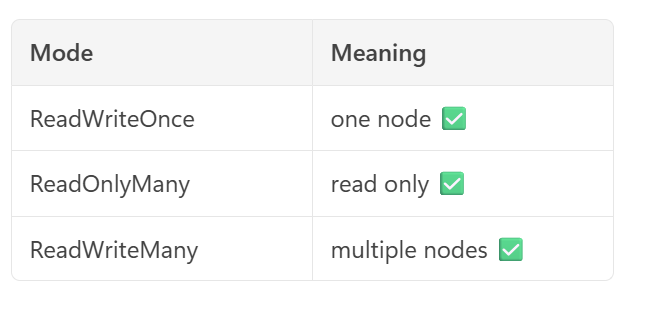

Interview answer :
In Kubernetes, storage is managed using Persistent Volumes and Persistent Volume Claims. A PersistentVolume represents the actual storage, while a PersistentVolumeClaim is a request for storage by a pod. The pod uses the PVC to access storage, ensuring data persists even if the pod is deleted or restarted.

✅ ✅ ⭐ 4. SERVICES

A Service in Kubernetes is used to expose a Pod or Deployment so it can be accessed from inside or outside the cluster.
To expose pod outside the world then service is needed.

TYPES OF SERVICES :
✅ 1. ClusterIP (Default ✅)
👉 Used for:
Internal access only ❌ external

✅ 2. NodePort ⭐
👉 Used for:
Expose outside cluster ✅

✅ 3. LoadBalancer
👉 Used for:
Cloud environments ✅
 
✅ Create service (vim service.yml)
apiVersion: v1
kind: Service
metadata:
  name: nginx-service
  namespace: nginx
spec:
  selector:
    app: nginx
  ports:
    - protocol: TCP
      port: 80
      targetPort: 80
  type: NodePort

✅ APPLY SERVICE:
kubectl apply -f service.yml

✅ VERIFY:
kubectl get svc -n nginx

✅ CHECK ALL RESOURCES
kubectl get all -n nginx : To see pod,service and deployment.


✅ ACCESS APPLICATION
✅ Option 1: NodePort (Recommended)
http://<EC2-IP>:<NodePort>

✅ Option 2: Port Forward (You used ✅)
kubectl port-forward service/nginx-service -n nginx 8080:80 --address=0.0.0.0
sudo -E kubectl port-forward service/nginx-service -n nginx 80:80 --address=0.0.0.0

👉 Access:
http://<EC2-IP>:8080 ✅

✅ ✅ ⭐ 13. INTERVIEW ANSWER
👉 Answer:
A Service in Kubernetes is used to expose pods and provide stable network access. Since pod IPs are dynamic, services ensure consistent communication using a stable endpoint. It also provides load balancing across multiple pods. Common types include ClusterIP, NodePort, and LoadBalancer.

Service = Expose pod to users ✅

# Ingress
Ingress = gateway that controls how users from the internet reach your applications inside Kubernetes.
Ingress is a smart router that manages external traffic and directs it to the right service inside a Kubernetes cluster.
It reroute the traffic on cluster.
To manage multiple microservice where we need ingress.

✅ With Ingress:
Single entry point (one IP/domain)
Routes traffic to different services based on rules

✅ 🧭 How Ingress Works
User → Ingress → Service → Pod

Step-by-step:
User hits a URL (e.g., example.com)
Ingress receives request
Ingress checks rules
Routes request to correct service
Service sends it to Pods


✅ 🧩 Key Components
1. Ingress Resource (YAML config)
Defines routing rules
2. Ingress Controller
Actual component that implements Ingress
Examples:

NGINX Ingress Controller ✅ (most common)
Traefik
HAProxy

👉 Important:
Ingress resource alone does nothing — you need an Ingress Controller

Example Ingress YAML :

apiVersion: networking.k8s.io/v1
kind: Ingress
metadata:
  name: my-ingress
spec:
  rules:
    - host: myapp.com
      http:
        paths:
          - path: /app
            pathType: Prefix
            backend:
              service:
                name: my-service
                port:
                  number: 80


# Statefulsets
A StatefulSet is a Kubernetes object used to manage stateful applications (apps that need to remember data or identity).

Once pod are deleted in statefulset it will recreate with same name.

✅ 🔄 Stateless vs Stateful (Important)

✔ Stateless apps (Deployment)
Pods are replaceable
No identity
No data persistence
Example:
Web apps

✔ Stateful apps (StatefulSet)
Pods have fixed identity
Data is stored and preserved
Pods are created in order
Example:
Databases (MySQL, MongoDB) ✅
Kafka, Redis

✅ 🧭 How StatefulSet Works
StatefulSet → Pods → Storage (PV)
Each pod:
Has unique name
Has its own volume
Has fixed identity


✅ 🚀 For Interview (Important Line)
StatefulSets are used for managing stateful applications like databases, where each pod requires stable identity, persistent storage, and ordered deployment.

Pratical:
1. created new folder : mkdir mysql
2. create a new namespace : vim namespace.yml
 kind: Namespace
 apiversion: v1
 metadata:
     name: mysql
     
kubctl apply -f namespace.yml 
3. create a new file : vim statefulset.yml
 Kind: SatefulSet.yml
 apiversion: apps/v1
 metadata:
     name: msql-statefulset
     namespace: mysql
 spec:
     replicas: 3
     selector: 
             matchLabels:
                 app: mysql
            template:
                metadata:
                    labels:
                        app: mysql
                    spec:
                        serviceName: mysql-service
                        container:
                         - name: mysql
                           image: mysql: 8.0
                           ports:
                            -containersPort: 3306
                            env:
                            -name: MYSQL_ROOT_PASSWORD
                            value: root

                            -name: MYSQL_DATABASE
                             value: devops

                             volumeMounts:
                             - name: mysql-data
                               mountPath: /var/lib/mysql

                            volumeClaimTemplates:
                            - metadata:
                                name: mysql-data
                                spec:
                                    accessModes: [ "ReadWriteOnce" ]
                                    storageClassName: "my-storage-class"
                                    resources:
                                         requests:
                                           storage: 1Gi

 kubctl apply -f namespace.yml

4. create a new service file : vim service.yml
 kind: Service
 apiVesrion: v1
 metadata:
     name: mysql-service
     namespace: mysql
 spec:
     ClusterIP: None  (This is called headless service as well)
     selector:
         app: mysql
     ports:
      -name: mysql
       protocol: TCP
       port: 3306
       targetPort: 3306
       
 kubctl apply -f namespace.yml

 5. kubectl get pods -n mysql
    kubectl exec -it pod-name -n mysql(namespace name) --bash
    mysql -u -root -p
    enter password
    mysql> now entered inside mysql database

# ConfigMaps
Configmap is a kubenetes object used to store none-senstive application configuration separately from the container image. It allows us to manage configuration independently of application code. 
For example, application URLs, environment names, ports, and logging settings can be stored in a ConfigMap and consumed by pods through environment variables or mounted files. This improves flexibility and avoids rebuilding Docker images for configuration changes.

✅ Hands-On Example
Step 1: Create ConfigMap
apiVersion: v1
kind: ConfigMap
metadata:
  name: app-config
data:
  ENVIRONMENT: production
  APP_NAME: nginx-app

Apply:
kubectl apply -f configmap.yml

Verify:
kubectl get configmap

Step 2: Use ConfigMap in Deployment
apiVersion: apps/v1
kind: Deployment
metadata:
  name: nginx-deployment
spec:
  replicas: 2

  selector:
    matchLabels:
      app: nginx

  template:
    metadata:
      labels:
        app: nginx

    spec:
      containers:
      - name: nginx
        image: nginx

        env:
        - name: ENVIRONMENT
          valueFrom:
            configMapKeyRef:
              name: app-config
              key: ENVIRONMENT

Verify:
kubectl exec -it <pod-name> -- env

# Secrets
A Secret is a Kubernetes object used to store sensitive information such as passwords, API keys, tokens, certificates, and credentials.

✅ Secret Types
Opaque (Most Common)
Used for:
    Passwords
    Tokens
    API Keys

Docker Registry Secret
Used for:
    Private Docker Hub images
    Private ECR images

TLS Secret
Used for:
    SSL Certificates
    HTTPS

    
✅ Hands-On Example

✅ Step 1: Create Secret (vim secret.yml)
Kind: Secret
apiVersion: v1
metadata:
    name: mysecret
    

✅ Step 2: Create Secret Using YAML

First Encode Values
Username : echo -n "admin" | base64
Output: YWRtaW4=

Password : echo -n "Admin@123" | base64
Output: QWRtaW5AMTIz

Create secret.yml
apiVersion: v1
kind: Secret
metadata:
  name: db-secret
  
type: Opaque

data:
  username: YWRtaW4=
  password: QWRtaW5AMTIz

Apply
kubectl apply -f secret.yml

✅ Step 3: Use Secret in Pod
apiVersion: v1
kind: Pod
metadata:
  name: nginx-pod

spec:
  containers:
  - name: nginx
    image: nginx

    env:
    - name: DB_USER
      valueFrom:
        secretKeyRef:
          name: db-secret
          key: username

    - name: DB_PASSWORD
      valueFrom:
        secretKeyRef:
          name: db-secret
          key: password
   
✅ Useful Commands

List Secrets
kubectl get secrets

Describe Secret
kubectl describe secret db-secret

Decode Secret
kubectl get secret db-secret -o yaml

Decode value:
echo "QWRtaW5AMTIz" | base64 -d

✅ Real Interview Answer
Kubernetes Secrets are used to store sensitive information such as passwords, API keys, and certificates. Instead of hardcoding credentials inside applications or YAML files, Secrets allow secure injection of sensitive data into Pods through environment variables or mounted volumes. This improves security and simplifies credential management.

# Resources and Limits 
Resources and Limits are used to control how much CPU and Memory a container can use.

✅ Request vs Limit
Request
The minimum resources Kubernetes guarantees.

Example:
requests:
  memory: "256Mi"
  cpu: "250m"
Meaning:
Memory: 256 MB guaranteed
CPU: 0.25 Core guaranteed

Limit
Maximum resources a container can use.

Example:
limits:
  memory: "512Mi"
  cpu: "500m"
Meaning:
Memory cannot exceed 512 MB
CPU cannot exceed 0.5 Core

✅ Example YAML
apiVersion: v1
kind: Pod
metadata:
  name: nginx-pod

spec:
  containers:
  - name: nginx
    image: nginx

    resources:
      requests:
        memory: "256Mi"
        cpu: "250m"

      limits:
        memory: "512Mi"
        cpu: "500m"

✅ Common Incident 1: OOMKilled

Interview Scenario
One of the most common incidents I handled was a pod getting restarted frequently.

Commands
kubectl get pods
Output:OOMKilled

Check details: kubectl describe pod <pod-name>

RCA
Application was consuming: 700Mi Memory

But limit was: 512Mi

Fix
Updated deployment: 
limits:
  memory: "1Gi"

Then: kubectl rollout restart deployment nginx-deployment

✅ Interview Answer
I checked the pod status and found it was getting OOMKilled. Using kubectl describe pod, I identified that the memory limit was lower than actual consumption. I increased the memory limit and restarted the deployment. After RCA, we adjusted resource allocation and added monitoring to prevent recurrence.

✅ Common Incident 2: High CPU Usage
Check Usage : kubectl top pod
Output: CPU = 950m
Limit: 500m

Fix
Scale deployment: kubectl scale deployment app --replicas=5
or
Increase CPU limit.

✅ Common Interview Questions
Q1. Difference between Request and Limit?
Answer:Request is the minimum resource guaranteed to a container and is used by the scheduler while placing pods. Limit is the maximum amount of resources that a container can consume.

Q2. What happens if memory limit is exceeded?
Answer: The container gets terminated and the pod may show OOMKilled status.

Q3. What happens if CPU limit is exceeded?
Answer:The container is throttled. CPU usage is restricted but the container usually does not get killed.

# Probes
Its way to checking your application is working or not.
Probes are health checks used by Kubernetes to determine whether a container is healthy, ready to accept traffic, or has started successfully.

✅ Types of Probes
There are 3 types:
1. Liveness Probe : Checks whether the application is alive.
   If it fails: Container restarted ✅
Example YAML
   livenessProbe:
  httpGet:
    path: /
    port: 80
  initialDelaySeconds: 10
  periodSeconds: 5

Explanation :
Check / every 5 seconds
Wait 10 seconds after startup

If probe fails repeatedly:
Restart container ✅

Liveness Probe checks whether the application is still running properly. If the application becomes unhealthy or hangs, Kubernetes restarts the container automatically.

2. Readiness Probe : Checks whether application is ready to receive traffic.

Example YAML :
readinessProbe:
  httpGet:
    path: /
    port: 80
  initialDelaySeconds: 5
  periodSeconds: 5

Readiness Probe determines whether a container is ready to serve requests. If it fails, Kubernetes removes the pod from service endpoints but does not restart it.

3. Startup Probe : Checks whether an application has started successfully.

Example YAML 
startupProbe:
  httpGet:
    path: /
    port: 80
  failureThreshold: 30
  periodSeconds: 10

Meaning :
Check every 10 sec
Allow 30 failures

Total:
300 sec startup time ✅

✅ Real Production Incident (Interview Story)

Incident : One of our applications was running, but users were getting errors.

Investigation
Checked pods: kubectl get pods

Everything looked healthy:
But application wasn't accessible.

Checked Probe Status : kubectl describe pod <pod-name>
Found: Readiness Probe Failed

RCA
Application couldn't connect to backend service.

Fix
Corrected configuration and restarted deployment:
kubectl rollout restart deployment app

Result
Readiness became healthy ✅
Traffic restored ✅

# Taint and Tolerations
Taints and Tolerations are used to control which Pods can be scheduled on specific Nodes.
Taint is way of telling kubernetes not to schedule pod on the particular node.

🧠 Easy Understanding
Think of a node as a VIP room.
Node says: ❌ Don't schedule any Pod here. This is called a Taint.
A Pod says: ✅ I can tolerate this restriction. This is called a Toleration.

✅ Taint Syntax
kubectl taint nodes worker-node1 app=database:NoSchedule

Untaint
kubectl taint nodes worker-node1 app=database:NoSchedule-

✅ Pod Without Toleration
Suppose Pod YAML:
apiVersion: v1
kind: Pod
metadata:
  name: nginx

spec:
  containers:
  - image: nginx
    name: nginx

Scheduler tries:
Node has taint ❌
Pod has no toleration ❌

Result:
Pending state ❌

✅ Pod With Toleration

apiVersion: v1
kind: Pod

metadata:
  name: nginx

spec:
  tolerations:
  - key: "app"
    operator: "Equal"
    value: "database"
    effect: "NoSchedule"

  containers:
  - name: nginx
    image: nginx

Now:
Node has taint ✅
Pod has toleration ✅

Pod gets scheduled ✅


✅ Real Interview Incident
Question:Tell me an incident involving scheduling problems.

Answer:
In one Kubernetes environment, a deployment remained in Pending state. I checked the pod events using:
kubectl describe pod <pod-name>
    
The error indicated that the node had a taint and the pod did not have a matching toleration. After reviewing node configuration using:
kubectl describe node <node-name>
    
I identified the taint. I then added the required toleration to the deployment YAML and redeployed the application. The pods were scheduled successfully. RCA showed that the deployment template was missing the required toleration for that dedicated node pool.

✅ Common Interview Questions
Q1. What is a Taint?
A taint is applied to a node to prevent pods from being scheduled unless they have matching tolerations.

Q2. What is a Toleration?
A toleration allows a pod to be scheduled onto a node that has a matching taint.

Q3. What happens if toleration is missing?
The pod remains in Pending state and cannot be scheduled on the tainted node.

# HPA  (Horizontal Pod Autoscaler) and VPA (Vertical Pod Autoscaler) 

✅ ✅ ⭐ Why Do We Need Autoscaling?
Suppose your application normally gets: 100 users ✅
Suddenly: 10,000 users ❌

Without scaling: 
High CPU ❌
Slow response ❌
Application crash ❌

Kubernetes solves this using:
HPA ✅
VPA ✅

✅ ✅ ⭐ HPA (Horizontal Pod Autoscaler)
HPA automatically increases or decreases the number of Pods based on CPU, Memory, or custom metrics.

✅ Example
Current:
nginx-deployment
Replicas = 2

Traffic increases.
HPA automatically changes
Replicas = 10 ✅

✅ Architecture
Users Increase
      ↓
CPU Usage High
      ↓
HPA
      ↓
More Pods Created

✅ HPA YAML
apiVersion: autoscaling/v2
kind: HorizontalPodAutoscaler
metadata:
  name: nginx-hpa

spec:
  scaleTargetRef:
    apiVersion: apps/v1
    kind: Deployment
    name: nginx-deployment

  minReplicas: 2
  maxReplicas: 10

  metrics:
  - type: Resource
    resource:
      name: cpu

      target:
        type: Utilization
        averageUtilization: 70

Meaning :
CPU > 70%
↓
Increase Pods

CPU Low
↓
Reduce Pods

✅ ✅ ⭐ VPA (Vertical Pod Autoscaler)
VPA automatically increases or decreases CPU and Memory allocated to a Pod.

Example
Before:
cpu: 500m
memory: 512Mi

After VPA:
cpu: 1000m
memory: 1Gi

✅ Architecture
Pod Uses More Memory
      ↓
VPA Detects
      ↓
Updates CPU/Memory
      ↓
Pod Gets More Resources

✅ VPA Example
apiVersion: autoscaling.k8s.io/v1
kind: VerticalPodAutoscaler
metadata:
  name: nginx-vpa

spec:
  targetRef:
    apiVersion: apps/v1
    kind: Deployment
    name: nginx-deployment

  updatePolicy:
    updateMode: Auto

✅ Real Production Example
Interview Answer
We observed frequent OOMKilled errors in one application. After analyzing resource usage, we implemented VPA. It automatically adjusted memory recommendations and increased limits, reducing pod restarts and improving application stability.

✅ Real Incident (INTERVIEW STORY)
Question : Tell me a scaling-related incident.

Answer : We experienced performance degradation due to increased application traffic. I checked resource utilization using:

kubectl top pods

CPU utilization was consistently above 85%. Since HPA was configured, Kubernetes automatically increased the number of pods from 3 to 7. Application performance improved immediately.
During RCA, we identified a traffic spike as the root cause and tuned HPA thresholds for future workloads.

# Node Affinity
Node Affinity is a Kubernetes feature that allows you to schedule Pods on specific Nodes based on node labels.

🧠 Simple Understanding
Imagine you have 3 nodes:
Node-1 → application servers Node-2 → database servers Node-3 → GPU servers
You want your database pod to run only on Node-2.
You use Node Affinity.

# Role Based Access Control
Role-Based Access Control (RBAC) is a Kubernetes authorization mechanism used to control who can access what resources and what actions they can perform in a Kubernetes cluster.

🧠 Simple Understanding
Think of a company:
TextEmployee
↓
Has certain permissionsManager
↓
Has more permissionsAdmin
↓
Has full permissions

Similarly in Kubernetes:
Developer→ View Pods ✅
DevOps Engineer→ Create Deployments ✅
Cluster Admin→ Full Access ✅

This is managed using RBAC.

✅ Why RBAC is Needed?
Without RBAC:Security risk 🚨

✅ RBAC Components
There are 4 important objects:
1. Role : A Role defines permissions within a Namespace.
Example: Allow a user to view Pods only.
2. ClusterRole : Role exists, but nobody uses it.
We need to assign it.
3. RoleBinding : Role works only inside a specific namespace.
ClusterRole works at the cluster level.
4. ClusterRoleBinding : Assign ClusterRole to users.

✅ Create role.yml (vim role.yml)

Kind: Role
apiVersion: rbac.authorization.k8s.io/v1
metadata:
    name: apachemanager
    namespace: apache
rules:
 -apiGroups: ["","apps",rbac.authorization.k8s.io","batch"]
  resources: ["deployment","pod","service"]
  verbs: ["get","apply","delete","watch","create","patch"]

Apply: kubectl apply -f role.yml
kubectl get role -n apache

✅ create service (vim service-account.yml)
Kind: service-account
apiVersion: v1
metadata:
    name: apache-user
    namespace: apache

Apply: kubectl apply -f role.yml
kubectl get serviceaccount -n apache
kubctl auth can-i get pods -n apache

✅ create binding (vim role-binding.yml)
Kind: RoleBinding
apiVersion: rbac.authorization.k8s.io/v1
metadata:
    name: apache-manager-rolebinding
    namespace: apache

subjects:
-kind: User
 name: apache-user
 apiGroup: rbac.authorization.k8s.io
   roleRef:
       kind: Role
       name: apache-manager
       apiGroup: rbac.authorization.k8s.io

Apply: kubectl apply -f role.yml
kubctl get rolebinding -n apache
kubectl auth can-i get pods -n apache --as=apache-user -n apache
kubectl auth can-i delete pods -n apache --as=apache-user -n apache

Note: with below rules user can onlyview the pods 
rules:
 -apiGroups: [""],"apps",rbac.authorization.k8s.io","batch"]
  resources: [[pods] #"deployment","service"]
  verbs: [[get] #get,"apply","delete","watch","create","patch","list"]


✅ Real Interview Incident
Question : Tell me a security-related issue you handled?
Answer : In one environment, developers required access to view pod logs but should not have deployment permissions. We implemented RBAC by creating a Role with get, list, and watch permissions on pods and logs. Then we assigned it through a RoleBinding. This helped maintain security and ensured developers only had the required access.

# Monitoring and Logging
Monitoring is the process of continuously observing applications, servers, containers, and infrastructure to ensure they are healthy, available, and performing as expected.

✅ Common Monitoring Tools
Infrastructure Monitoring
Prometheus
Grafana
CloudWatch (AWS)
Datadog
Nagios
Zabbix

Kubernetes Monitoring
Prometheus
Grafana
Metrics Server

✅ Monitoring Architecture

Application
      ↓
Metrics Collection
      ↓
Prometheus
      ↓
Grafana Dashboard
      ↓
Alerts
      ↓
DevOps Team

Goto repo : https://github.com/LondheShubham153/kubestarter/tree/main/kind-cluster

First apply dashboard manifest file
Create cluster (vim dashboard-admin-user)
 Kind: ServiceAccount
 apiVersion: v1
 metadata:
     name: admin-user
     namespace: kubernetes-dashboard

 -----
 Kind: ClusterRoleBinding
 apiVersion: rbac.authorization.k8.io/v1
 metadata:
     name: admin-user-binding
     namespace: kubernetes-dashboard
 subjects:
    -kind: ServiceAccount
     name: admin-user
     namespace: kubernetes-dashboard
 roleRef:
     apiGroup: rbac.authorization.k8.io
     kind: ClusterRole
     name: cluster-admin
     
Apply:
kubectl apply -f dashboard-admin-user.yml

create token for admin-user so that user can asccess dashboard
kubectl -n kubernetes-dashboard create token admin-user

kubectl proxy --address=0.0.0.0 --accept-hosts='.*'

✅ What is Logging ?
Logging is the process of collecting and storing application, system, and container logs to help troubleshoot issues and perform root cause analysis.

✅ Common Logging Tools
Splunk
ELK Stack (Elasticsearch, Logstash, Kibana)
Fluentd
Fluent Bit
CloudWatch Logs

✅ Logging Architecture
Application
     ↓
Logs Generated
     ↓
Fluentd / Fluent Bit
     ↓
Elasticsearch
     ↓
Kibana

✅ Prometheus
Prometheus is an open-source monitoring tool used to collect metrics from applications and infrastructure.

Collects:
CPU Usage
Memory Usage
Request Count
Pod Metrics
Node Metrics

✅ Grafana
Grafana is a dashboard and visualization tool used to display monitoring data.

In Grafana you can see:
CPU Usage Graph
Memory Usage Graph
Pod Health
Node Status
Network Traffic
Application Latency

✅ ELK Stack
Components
Elasticsearch
Stores logs.
Logstash
Processes logs.
Kibana
Visualizes logs.

Prometheus = Collects Metrics ✅
Grafana = Shows Metrics ✅

✅ Interview Question
How do you monitor Kubernetes?
I monitor Kubernetes health using tools like Prometheus and Grafana. I track CPU, memory, pod health, node utilization, and application performance. For troubleshooting, I use kubectl commands such as kubectl top pods, kubectl get pods, and kubectl describe pod.

✅ Interview Question
How do you perform troubleshooting?
First, I check monitoring dashboards and alerts to identify impacted resources. Then I analyze logs using kubectl logs or centralized logging tools like Splunk. After identifying the root cause, I implement the fix and document RCA to prevent recurrence.

✅ How have you used Prometheus and Grafana?
I used Prometheus for collecting Kubernetes and application metrics such as CPU, memory utilization, pod health, and request rates. Grafana was used to create dashboards for visualization and monitoring. During incidents, I used Grafana dashboards to identify abnormal resource utilization and Prometheus alerts to proactively detect issues before they impacted users.

✅ Real DevOps Workflow
Alert Received
      ↓
Check Dashboard
      ↓
Identify Problem
      ↓
Check Logs
      ↓
Find RCA
      ↓
Fix Issue
      ↓
Close Incident

# Custom Resource Definitions
A Custom Resource Definition (CRD) allows you to create your own Kubernetes resource type, just like Pods, Deployments, or Services.

🧠 Simple Analogy
Imagine Kubernetes is a smartphone.
By default it comes with:
Phone
Camera
Calculator

But you install a new app and get new functionality.
Similarly:
CRD = Install new capability in Kubernetes ✅

✅ Custom Resource Example
✅ Step 1: Create a CRD

Example: 
apiVersion: apiextensions.k8s.io/v1
kind: CustomResourceDefinition
metadata:
  name: databases.company.com
spec:
  group: company.com

  versions:
  - name: v1
    served: true
    storage: true

    schema:
      openAPIV3Schema:
        type: object
  scope: Namespaced
  names:
    plural: databases
    singular: database
    kind: Database

Apply: kubectl apply -f crd.yaml

✅ Verify CRD
kubectl get crd

Output: databases.company.com

✅ Step 2: Create Custom Resource
Now Kubernetes understands: Database

Create:
apiVersion: company.com/v1
kind: Database

metadata:
  name: mysql-db

spec:
  engine: mysql
  version: "8.0"

Apply: kubectl apply -f database.yaml

✅ Verify
kubectl get databases
Output: mysql-db


# Helm
Helm is a package manager for Kubernetes that helps deploy, manage, upgrade, and version Kubernetes applications using reusable templates called Charts.

Helm is often called the Package Manager of Kubernetes, just like:
apt     → Ubuntu package manager
yum     → RHEL package manager
npm     → Node.js package manager
Helm    → Kubernetes package manager

✅ Helm Directory Structure
mychart/
├── Chart.yaml
├── values.yaml
├── templates/
│   ├── deployment.yaml
│   ├── service.yaml
│   ├── ingress.yaml


✅ Important Helm Components
1. Helm Chart : A Helm package is a collection of templated Kubernetes manifests used to deploy an application.
Contains:
Deployment
Service
ConfigMap
Secret

2. Release : A Release is an instance of a deployed Helm chart inside a Kubernetes cluster.
Example: helm install my-nginx nginx-chart

3. Repository : Collection of charts.
Example: helm repo add bitnami https://charts.bitnami.com/bitnami

Hands on Example: 
Install helm dev-acpache:
Command: helm install dev-apache apache-helm -n dev-apache --create-namespace

kubectl get pods -n dev-apache

Install helm prd-acpache:
Command: helm install prd-apache apache-helm -n prd-apache --create-namespace

kubectl get pods -n prd-apache

✅ Create a nodejs app :
Step 1: helm create node-js-app
Step 2: upgrade the value.
Step 3: helm package node-js-app/
Step 4: helm install dev-node-js-app node-js-app -n dev-node --create-namespace
Step 5: kubectl get pods -n dev-node
Step 6: kubectl get svc -n dev-node

search anything on helm : helm search repo nginx 

✅ Real Interview Scenario
Question Tell me how you've used Helm?
Answer
I used Helm to deploy and manage Kubernetes applications such as Prometheus, Grafana, and Nginx. Helm simplified deployment by packaging all Kubernetes resources into reusable charts. I also used Helm upgrades for application updates and Helm rollback during deployment failures.

✅ Real Incident Example
Deployment Failure After Upgrade :
During an application upgrade using Helm, the new release caused application instability. I checked the Helm release history using: helm history myapp

Then I rolled back to the previous stable version: helm rollback myapp 1

This restored service quickly while RCA was performed.

# Service Mesh
A Service Mesh is an infrastructure layer that manages service-to-service communication in a microservices environment.

✅ Key Components
1. Data Plane: Handles actual traffic.
Usually consists of: Envoy Proxy

2. Control Plane: Controls policies and traffic.
Example: Istiod (Istio)

# Init conatiner and sidebar conatiner
Init Containers are used to perform startup tasks before the application container starts. They run sequentially and must complete successfully before the main container begins execution.

A Sidecar Container is an additional container running alongside the main application container within the same Pod.
A sidecar conatiner is the helper of main conatiner.

Both containers run simultaneously.

✅ Interview Scenario
Q1: Why do we need Service Mesh?
✅ Answer:
In a microservices architecture, multiple services communicate with each other. Managing security, retries, observability, and traffic routing individually in every application becomes complex. A Service Mesh provides a centralized way to manage service-to-service communication, security, monitoring, and traffic policies without changing application code.

Q2. What is Istio?
Istio is a popular Service Mesh that provides traffic management, security, observability, and policy enforcement for Kubernetes workloads.

Q3. What is a Sidecar Proxy?
A sidecar proxy, such as Envoy, runs alongside the application container and handles network communication on behalf of the application.
Sidecar proxy per microservice to handle ingress/egress traffic between services in the cluster and from a service to external services.

Q4. What are the benefits of Service Mesh?
Traffic Management ✅
Security (mTLS) ✅
Observability ✅
Retries ✅
Load Balancing ✅



# Chat Application (Microservices and Mongodb) (On Minikube local)

Chat Application on k8 -3 Tier

1. React------>Docker------->Pod------->Deployment--------->Services ------
2. NodeJs------>Docker------->Pod------->Deployment--------->Services------- Ingress
3. Mongodb------>Docker------->Pod------->Deployment--------->Services------

Pre-requisites:
Install Docker Desktop.
Install Minikube.
Install VScode.
Login to Docker hub. (So that whenever will build docker images will get pushed to dockerhub).

Steps to start in vs code:
1.Open terminal: minikube start --driver=docker
2.Check the status minikube is working or not: minikube status (make sure host,kubelet,apiserver are running and kubeconfig is configured)
3.Clone Project: git clone repourl
4.docker login (generate personal access token from docker hub).
5.Now build the image from backend, move to path backend and type: docker build -t gunjan147/chatapp-backend:latest .
6.docker images (gunjan147/chatapp-backend image will be present).
7. docker push gunjan147/chatapp-backend:latest (after build push the image to docker hub/repo)
8. docker build -t gunjan147/chatapp-frontend:latest .
9. docker push gunjan147/chatapp-frontend:latest (after build push the image to docker hub/repo)
10.Now will create POD
11. create new folder named as k8s
12. create file namespace.yml
13. create file backend-deployment.yml,frontend-deployment.yml and mongodb-deployment.yml
14. create mongodb-pv.yml and mongodb-pvc.yml.
15. kubctl apply -f mongodb-pv.yml--->kubectl apply -f mongodbpvc.yml---->kubectl apply -f mongodb-deployment.yml
16. create frontend-service.yml,backend-service.yml,mangodb-service.yml. Apply->
17. create secrets.yml and call in backend-deployment.yml






# Kubernetes Monitoring 

Observability :
Monitoring
Logging
Tracing
Alerting

Helm: it is package manager for kubernetes manifest file where you can install or manage , delete, uninstall with lots of repository or any application which is to deploy on kubenetes. like prometheus,grafan,argoCG thease all it installed.


Step 1: Do the ssh
step 2: sudo apt-get update (To update all application)
step 3: sudo apt-get install docker.io -y (installing docker)
step 4: docker ps (to see the conatiner which all created)
step 5: sudo usermod -aG $USER && newgrp docker (This command allows your current user to run Docker commands without using sudo every time.)
step 6: git clone https://github.com/gunupatel/k8s-kind-voting-app.git
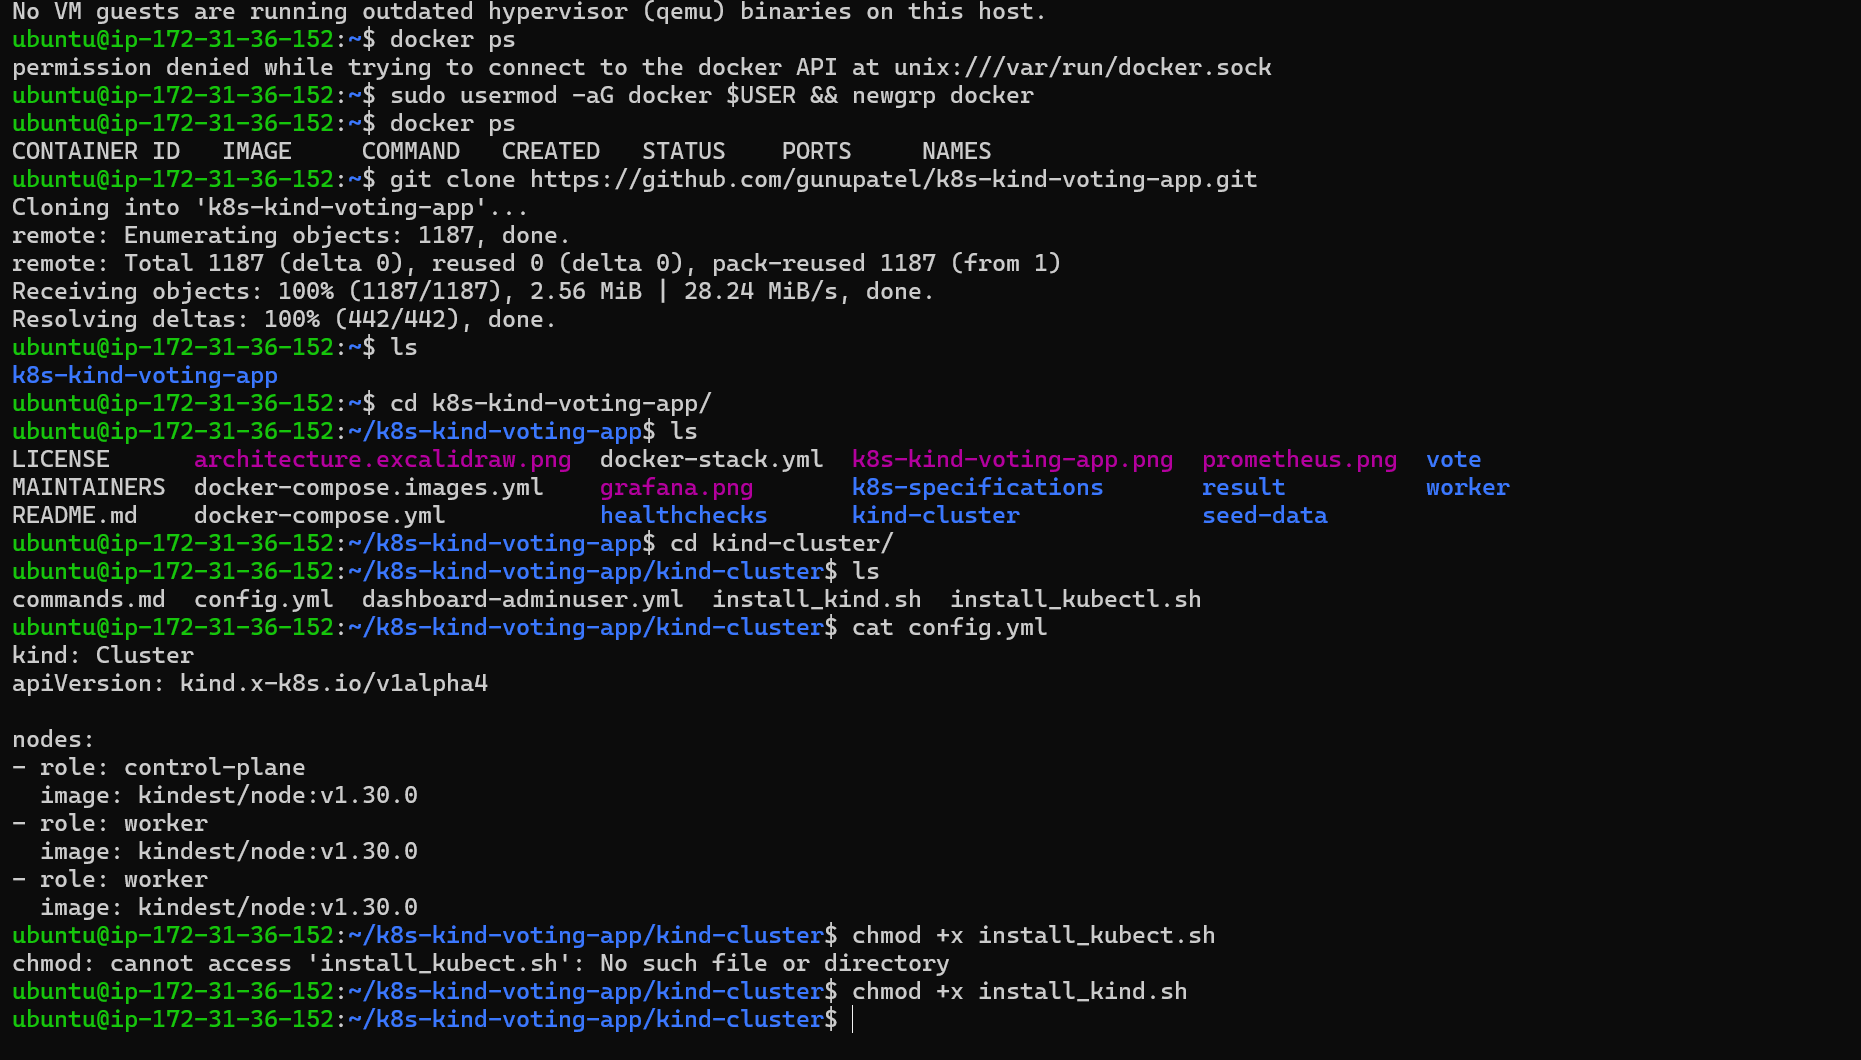
Step 7: install kind
step 8: create cluster with kind(kind create cluster --config=config.yml --name=my-cluster)
Delete Cluster: kind delete cluster --name=my-cluster
get cluster: kind get clusters

step 9: install kubectl to manage the cluster
step 10: now will install app on current cluster
step 11: deploy the application (kubectl apply -f .) ->kubectl get all
step 12: install helm (curl -fsSL -o get_helm.sh https://raw.githubusercontent.com/helm/helm/main/scripts/get-helm-3
chmod 700 get_helm.sh
./get_helm.sh)
step 13: create a prometheus repo so, with this all prometheus helm chart, manifest file all will get installed. (helm repo add prometheus-community https://prometheus-community.github.io/helm-charts)

do helm repo list: with this command we can see which all helm chats are downloded.

step 13: Install (helm repo add stable https://charts.helm.sh/stable)
step 14: update all chat with latest update (helm repo update)
step 15: kubenetes and monitoring are installed (kubectl create namespace monitoring)
step 16: deploy prometheus & prometheus-kind-stack installed (helm install kind-prometheus prometheus-community/kube-prometheus-stack --namespace monitoring --set prometheus.service.nodePort=30000 --set prometheus.service.type=NodePort --set grafana.service.nodePort=31000 --set grafana.service.type=NodePort --set alertmanager.service.nodePort=32000 --set alertmanager.service.type=NodePort --set prometheus-node-exporter.service.nodePort=32001 --set prometheus-node-exporter.service.type=NodePort)
step 17: kubectl get svc -n monitoring
step 18: kubectl get namespace
step 19: kubectl get pods -n monitoring
step 20: will access prometheus & gafana by doing port-forward (kubectl port-forward svc/kind-prometheus-kube-promo-prometheus -n monitoring 9090:9090 --address=0.0.0.0 &) also expose the port on ec2 on security group. you can access the prometheus on ip:9090

Exit cannot do due to memory issues.